<a href="https://colab.research.google.com/github/deepkaur09/airport-surface-safety-system/blob/main/AS_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Setup**

Mounts Google Drive (for video input/output), installs required libraries (YOLOv8, OpenCV, NumPy, Matplotlib), and verifies the video file loads correctly with the expected resolution and frame count.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install ultralytics opencv-python-headless matplotlib numpy -q
print("All libraries installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 6.4 MB/s eta 0:00:00
All libraries installed!


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import Polygon, Patch
from collections import deque
import csv
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)
print("✅ All libraries ready – Airport AI setup complete!")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
OpenCV version: 5.0.0
NumPy version: 2.1.3
✅ All libraries ready – Airport AI setup complete!


In [5]:
video_path = "/content/drive/MyDrive/AirportVideo/airport.mp4"
cap = cv2.VideoCapture(video_path)

print("Video opened:", cap.isOpened())
print("Total frames:", int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))
print("FPS:", cap.get(cv2.CAP_PROP_FPS))
print("Width:", int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)))
print("Height:", int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))

cap.release()

Video opened: True
Total frames: 729
FPS: 25.0
Width: 1920
Height: 1080


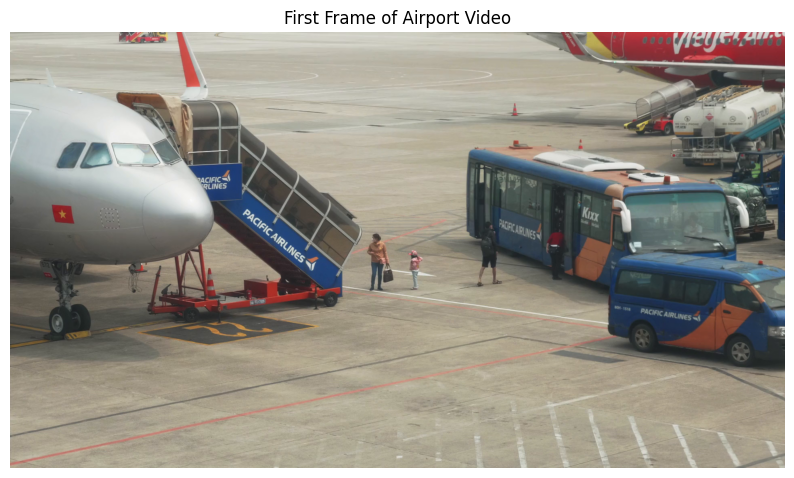

In [ ]:
cap = cv2.VideoCapture("/content/drive/MyDrive/AirportVideo/airport.mp4")

# Read the first frame
ret, frame = cap.read()

# Convert color from BGR to RGB for display
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# Show it
plt.figure(figsize=(10, 6))
plt.imshow(frame_rgb)
plt.title("First Frame of Airport Video")
plt.axis("off")
plt.show()

cap.release()


0: 384x640 4 persons, 2 cars, 4 airplanes, 1 bus, 376.1ms
Speed: 27.7ms preprocess, 376.1ms inference, 42.0ms postprocess per image at shape (1, 3, 384, 640)


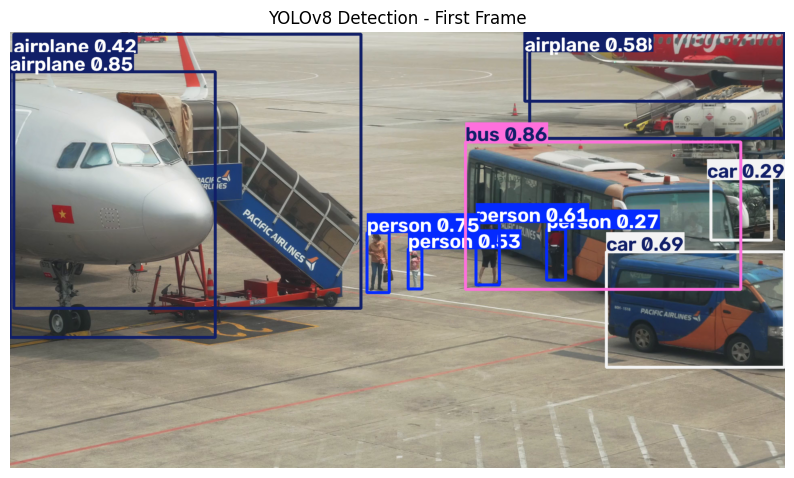

In [ ]:
# Read one frame from your video
cap = cv2.VideoCapture("/content/drive/MyDrive/AirportVideo/airport.mp4")
ret, frame = cap.read()
cap.release()

# Run YOLO detection on that frame
results = model(frame)

# Show the frame with detections drawn on it
annotated_frame = results[0].plot()
annotated_frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(annotated_frame_rgb)
plt.title("YOLOv8 Detection - First Frame")
plt.axis("off")
plt.show()

**Phase 2: Detection on Full Video**

Running YOLO on each frame which helps to detect different objects like aircraft or a person with their confidence scores provided.

In [ ]:
# Open video
cap = cv2.VideoCapture("/content/drive/MyDrive/AirportVideo/airport.mp4")

# Get video properties
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Setup output video writer
output_path = "/content/drive/MyDrive/AirportVideo/airport_detected.mp4"
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

print(f"Processing {total_frames} frames...")

frame_count = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Run YOLO on each frame
    results = model(frame, verbose=False)
    annotated_frame = results[0].plot()

    # Write to output video
    out.write(annotated_frame)
    frame_count += 1
    print(f"Frame {frame_count}/{total_frames}", end="\r")

cap.release()
out.release()
print(f"\nDone! Saved to your Drive as airport_detected.mp4")

Processing 387 frames...
Frame 387/387
Done! Saved to your Drive as airport_detected.mp4


**Phase 3: Object Tracking**

Upgrades detection to tracking - assigns each object with an ID which stays consistent across all the frames. It will later help whenever when on generating alerts, calculating speed and distance.

In [ ]:
# Open video
cap = cv2.VideoCapture("/content/drive/MyDrive/AirportVideo/airport.mp4")

# Setup output video
output_path = "/content/drive/MyDrive/AirportVideo/airport_tracked.mp4"
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

frame_count = 0
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print("Starting tracking...")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # track=True is the only difference from before!
    results = model.track(frame, persist=True, verbose=False)
    annotated_frame = results[0].plot()

    out.write(annotated_frame)
    frame_count += 1
    print(f"Frame {frame_count}/{total_frames}", end="\r")

cap.release()
out.release()
print(f"\nDone! Saved as airport_tracked.mp4")

Starting tracking...
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 2 packages in 698ms
Prepared 1 package in 272ms
Installed 1 package in 1ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 1.3s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

Frame 387/387
Done! Saved as airport_tracked.mp4


**Phase 4: Speed & Proximity-Based Danger Detection**

Tracks each objects speed and compare it with previous frames. If two objects are closer to each other than the assigned danger distance value means that alerts will be generated. The severity depends on if both objects are moving towards eachother or only one of them is in motion.

In [ ]:
cap = cv2.VideoCapture("/content/drive/MyDrive/AirportVideo/airport.mp4")
output_path = "/content/drive/MyDrive/AirportVideo/airport_smart_v2.mp4"
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

previous_positions = {}

#two objects should be 150 pixels apart from eachother
DANGER_DISTANCE = 150

def get_center(box):
    x1, y1, x2, y2 = box
    return (int((x1+x2)/2), int((y1+y2)/2))

def get_speed(obj_id, center, prev_positions):
    if obj_id in prev_positions:
        px, py = prev_positions[obj_id]
        return np.sqrt((center[0]-px)**2 + (center[1]-py)**2)
    return 0

frame_count = 0
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print("Processing smart detection v2...")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    results = model.track(frame, persist=True, conf=0.35, verbose=False)

    current_positions = {}
    objects = []

    if results[0].boxes.id is not None:
        for box, obj_id, cls, conf in zip(
            results[0].boxes.xyxy,
            results[0].boxes.id,
            results[0].boxes.cls,
            results[0].boxes.conf
        ):
            obj_id = int(obj_id)
            center = get_center(box.tolist())
            speed = get_speed(obj_id, center, previous_positions)
            label = model.names[int(cls)]

            current_positions[obj_id] = center
            objects.append({
                "id": obj_id,
                "center": center,
                "speed": speed,
                "label": label,
                "box": box.tolist()
            })

            # Draw box and label
            x1,y1,x2,y2 = [int(v) for v in box.tolist()]
            cv2.rectangle(frame, (x1,y1), (x2,y2), (0,255,0), 2)
            cv2.putText(frame, f"id:{obj_id} {label} {conf:.2f}",
                       (x1,y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)

    # Check for dangers between object pairs
    for i in range(len(objects)):
        for j in range(i+1, len(objects)):
            o1, o2 = objects[i], objects[j]
            dist = np.sqrt((o1["center"][0]-o2["center"][0])**2 +
                          (o1["center"][1]-o2["center"][1])**2)

            both_moving = o1["speed"] > 3 and o2["speed"] > 3
            one_moving = o1["speed"] > 3 or o2["speed"] > 3

            # Midpoint between the two objects
            mid_x = (o1["center"][0] + o2["center"][0]) // 2
            mid_y = (o1["center"][1] + o2["center"][1]) // 2

            if dist < DANGER_DISTANCE:
                if both_moving:
                    # RED alert — two moving objects close together
                    cv2.putText(frame, f"DANGER: {o1['label']} & {o2['label']}!",
                               (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,255), 3)
                    cv2.circle(frame, (mid_x, mid_y), 60, (0,0,255), 3)

                elif one_moving:
                    # ORANGE warning — one moving one stationary
                    cv2.putText(frame, f"WARNING: {o1['label']} near {o2['label']}",
                               (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,165,255), 2)
                    cv2.circle(frame, (mid_x, mid_y), 60, (0,165,255), 3)

    previous_positions = current_positions
    out.write(frame)
    frame_count += 1
    print(f"Frame {frame_count}/{total_frames}", end="\r")

cap.release()
out.release()
print(f"\nDone! Saved as airport_smart_v2.mp4")

Processing smart detection v2...
Frame 387/387
Done! Saved as airport_smart_v2.mp4


**Phase 5: Trajectory Prediction**

It stores each object's last 10 positions and then makes a prediction based on that for 15 frames ahead with the help of simple mathematical computation. If two objects appears to be colliding in the near future, a warning is given ahead of time. Limitation: this assumes constant speed and direction, so it does not work well if the objects are turning or changing speed.




In [ ]:
cap = cv2.VideoCapture("/content/drive/MyDrive/AirportVideo/airport.mp4")
output_path = "/content/drive/MyDrive/AirportVideo/airport_trajectory.mp4"
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

# Store last 10 positions for each object to predict trajectory
position_history = {}
HISTORY_LENGTH = 10
DANGER_DISTANCE = 150

def get_center(box):
    x1, y1, x2, y2 = box
    return (int((x1+x2)/2), int((y1+y2)/2))

def predict_future_position(history, steps=15):
    if len(history) < 2:
        return None
    # Calculate average movement direction from last few positions
    dx = history[-1][0] - history[-2][0]
    dy = history[-1][1] - history[-2][1]
    # Predict where object will be in `steps` frames
    future_x = int(history[-1][0] + dx * steps)
    future_y = int(history[-1][1] + dy * steps)
    return (future_x, future_y)

frame_count = 0
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print("Processing trajectory prediction...")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    results = model.track(frame, persist=True, conf=0.35, verbose=False)

    objects = []

    if results[0].boxes.id is not None:
        for box, obj_id, cls, conf in zip(
            results[0].boxes.xyxy,
            results[0].boxes.id,
            results[0].boxes.cls,
            results[0].boxes.conf
        ):
            obj_id = int(obj_id)
            center = get_center(box.tolist())
            label = model.names[int(cls)]

            # Update position history for this object
            if obj_id not in position_history:
                position_history[obj_id] = deque(maxlen=HISTORY_LENGTH)
            position_history[obj_id].append(center)

            # Draw box and label
            x1,y1,x2,y2 = [int(v) for v in box.tolist()]
            cv2.rectangle(frame, (x1,y1), (x2,y2), (0,255,0), 2)
            cv2.putText(frame, f"id:{obj_id} {label}",
                       (x1,y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)

            # Draw trail — where object has been
            history = list(position_history[obj_id])
            for k in range(1, len(history)):
                cv2.circle(frame, history[k], 3, (255,255,0), -1)

            # Draw predicted future position
            future = predict_future_position(position_history[obj_id])
            if future:
                fx, fy = future
                # keeps predicted points within the frame
                fx = max(0, min(fx, width-1))
                fy = max(0, min(fy, height-1))
                cv2.circle(frame, (fx, fy), 8, (0,0,255), -1)
                cv2.arrowedLine(frame, center, (fx,fy), (0,0,255), 2)
                cv2.putText(frame, "predicted",
                           (fx+5, fy), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0,0,255), 1)

            objects.append({
                "id": obj_id,
                "center": center,
                "future": future,
                "label": label
            })

    # Check if any two predicted positions will collide
    for i in range(len(objects)):
        for j in range(i+1, len(objects)):
            o1, o2 = objects[i], objects[j]
            if o1["future"] and o2["future"]:
                future_dist = np.sqrt(
                    (o1["future"][0]-o2["future"][0])**2 +
                    (o1["future"][1]-o2["future"][1])**2
                )
                if future_dist < DANGER_DISTANCE:
                    cv2.putText(frame,
                               f"COLLISION PREDICTED: {o1['label']} & {o2['label']}",
                               (50, 80), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,0,255), 2)

    out.write(frame)
    frame_count += 1
    print(f"Frame {frame_count}/{total_frames}", end="\r")

cap.release()
out.release()
print(f"\nDone! Saved as airport_trajectory.mp4")

Processing trajectory prediction...


**Phase 5.5: Safety Alert Report (CSV Logging)**

Altogether works for the alerts generated upon speed based movement and future prediction. It writes the alerts into a csv file with labels such as object ID, object type, severity and distance from one-another rather than putting it on a video.

In [ ]:
cap = cv2.VideoCapture("/content/drive/MyDrive/AirportVideo/airport.mp4")
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

position_history = {}
HISTORY_LENGTH = 10
DANGER_DISTANCE = 150

def get_center(box):
    x1, y1, x2, y2 = box
    return (int((x1+x2)/2), int((y1+y2)/2))

def get_speed(obj_id, center, history):
    if obj_id in history and len(history[obj_id]) >= 2:
        prev = history[obj_id][-2]
        return np.sqrt((center[0]-prev[0])**2 + (center[1]-prev[1])**2)
    return 0

def predict_future_position(history, steps=15):
    if len(history) < 2:
        return None
    dx = history[-1][0] - history[-2][0]
    dy = history[-1][1] - history[-2][1]
    return (int(history[-1][0] + dx * steps), int(history[-1][1] + dy * steps))

# Create CSV file
csv_path = "/content/drive/MyDrive/AirportVideo/safety_alerts.csv"
csvfile = open(csv_path, "w", newline="")
writer = csv.writer(csvfile)
writer.writerow(["Frame", "Time(s)", "Object1_ID", "Object1_Type",
                 "Object2_ID", "Object2_Type", "Alert_Type",
                 "Distance(px)", "Severity"])

frame_count = 0
total_alerts = 0
print("Generating safety alert report...")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    results = model.track(frame, persist=True, conf=0.35, verbose=False)
    objects = []

    if results[0].boxes.id is not None:
        for box, obj_id, cls, conf in zip(
            results[0].boxes.xyxy,
            results[0].boxes.id,
            results[0].boxes.cls,
            results[0].boxes.conf
        ):
            obj_id = int(obj_id)
            center = get_center(box.tolist())
            label = model.names[int(cls)]

            if obj_id not in position_history:
                position_history[obj_id] = deque(maxlen=HISTORY_LENGTH)
            position_history[obj_id].append(center)

            speed = get_speed(obj_id, center, position_history)
            future = predict_future_position(position_history[obj_id])

            objects.append({
                "id": obj_id,
                "center": center,
                "speed": speed,
                "future": future,
                "label": label
            })

    # Check every pair of objects
    for i in range(len(objects)):
        for j in range(i+1, len(objects)):
            o1, o2 = objects[i], objects[j]

            dist = np.sqrt((o1["center"][0]-o2["center"][0])**2 +
                          (o1["center"][1]-o2["center"][1])**2)

            time_sec = round(frame_count / fps, 2)
            both_moving = o1["speed"] > 3 and o2["speed"] > 3
            one_moving = o1["speed"] > 3 or o2["speed"] > 3

            # Check current proximity alerts
            if dist < DANGER_DISTANCE:
                if both_moving:
                    writer.writerow([frame_count, time_sec,
                                    o1["id"], o1["label"],
                                    o2["id"], o2["label"],
                                    "DANGER", round(dist), "HIGH"])
                    total_alerts += 1
                elif one_moving:
                    writer.writerow([frame_count, time_sec,
                                    o1["id"], o1["label"],
                                    o2["id"], o2["label"],
                                    "WARNING", round(dist), "MEDIUM"])
                    total_alerts += 1

            # Check predicted collision
            if o1["future"] and o2["future"]:
                future_dist = np.sqrt(
                    (o1["future"][0]-o2["future"][0])**2 +
                    (o1["future"][1]-o2["future"][1])**2)
                if future_dist < DANGER_DISTANCE:
                    writer.writerow([frame_count, time_sec,
                                    o1["id"], o1["label"],
                                    o2["id"], o2["label"],
                                    "COLLISION PREDICTED",
                                    round(future_dist), "CRITICAL"])
                    total_alerts += 1

    frame_count += 1
    print(f"Frame {frame_count}/{total_frames}", end="\r")

cap.release()
csvfile.close()
print(f"\nDone! Total alerts logged: {total_alerts}")
print(f"Report saved to: safety_alerts.csv")

Generating safety alert report...
Frame 387/387
Done! Total alerts logged: 246
Report saved to: safety_alerts.csv


**Phase 6: Airport Map Creation**

Plots a 2D Airport map in metres distance showing taxiways, runways, terminal, restricted zone and hold short lines. This works as a reference layer for converting video positions into real-world locations in the next phase.

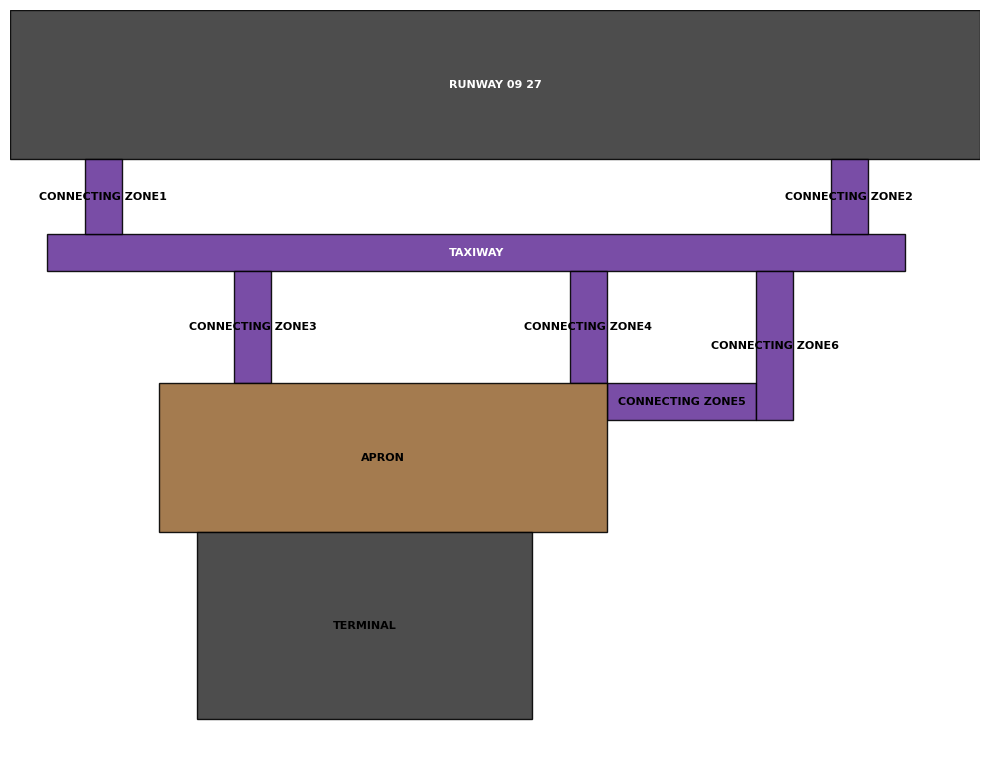

In [12]:
airport_map = {
    "runway_09_27": {
        "coords": [(0, 800), (0, 1000), (1300, 1000), (1300, 800)],
        "color": "#3a3a3a",
        "type": "runway"
    },
    "taxiway": {
        "coords": [(50,700), (50,650),(1200, 650), (1200, 700)],
        "color": "#6a3a9d",
        "type": "taxiway"
    },
    "connecting_zone1": {
        "coords": [(100, 700), (150, 700), (150, 800), (100, 800)],
        "color": "#6a3a9d",
        "type": "connecting_zone1"
    },
    "connecting_zone2": {
        "coords": [(1150, 700), (1100, 700), (1100, 800), (1150, 800)],
        "color": "#6a3a9d",
        "type": "connecting_zone2"
    },
    "connecting_zone3": {
        "coords": [(300, 500), (300, 650), (350, 650), (350, 500)],
        "color": "#6a3a9d",
        "type": "connecting_zone3"
    },
    "connecting_zone4": {
        "coords": [(800, 500), (800, 650), (750, 650), (750, 500)],
        "color": "#6a3a9d",
        "type": "connecting_zone4"
    },
    "connecting_zone5": {
        "coords": [(800, 500), (1000, 500), (1000, 450), (800, 450)],
        "color": "#6a3a9d",
        "type": "connecting_zone5"
    },
    "connecting_zone6": {
        "coords": [(1000, 450), (1000, 650), (1050, 650), (1050, 450)],
        "color": "#6a3a9d",
        "type": "connecting_zone6"
    },
    "apron": {
        "coords": [(200, 500), (200, 300), (800, 300), (800, 500)],
        "color": "#9a6d3c",
        "type": "apron"
    },
    "terminal": {
        "coords":[(250, 300), (250, 50), (700, 50), (700, 300)],
        "color": "#3a3a3a",
        "type": "terminal"
    },
}

def draw_airport_map(airport_map):
  fig, ax = plt.subplots(figsize=(10, 10))
  # background grass
  ax.set_facecolor("#a9d6a0")

  for name, zone in airport_map.items():
    poly = Polygon(zone["coords"], closed=True,
                        facecolor=zone["color"], edgecolor="black",
                        linewidth=1, alpha=0.9)
    ax.add_patch(poly)
    cx = np.mean([p[0] for p in zone["coords"]])
    cy = np.mean([p[1] for p in zone["coords"]])
    label_color = "white" if zone["type"] in ["runway", "taxiway"] else "black"
    ax.text(cx, cy, name.replace("_", " ").upper(), ha="center", va="center",
                 fontsize=8, weight="bold", color=label_color)

  ax.set_xlim(0, 1300)
  ax.set_ylim(0, 1000)
  ax.set_aspect('equal')
  ax.axis('off')
  plt.tight_layout()
  plt.show()

draw_airport_map(airport_map)

Frame size: width=1920, height=1080


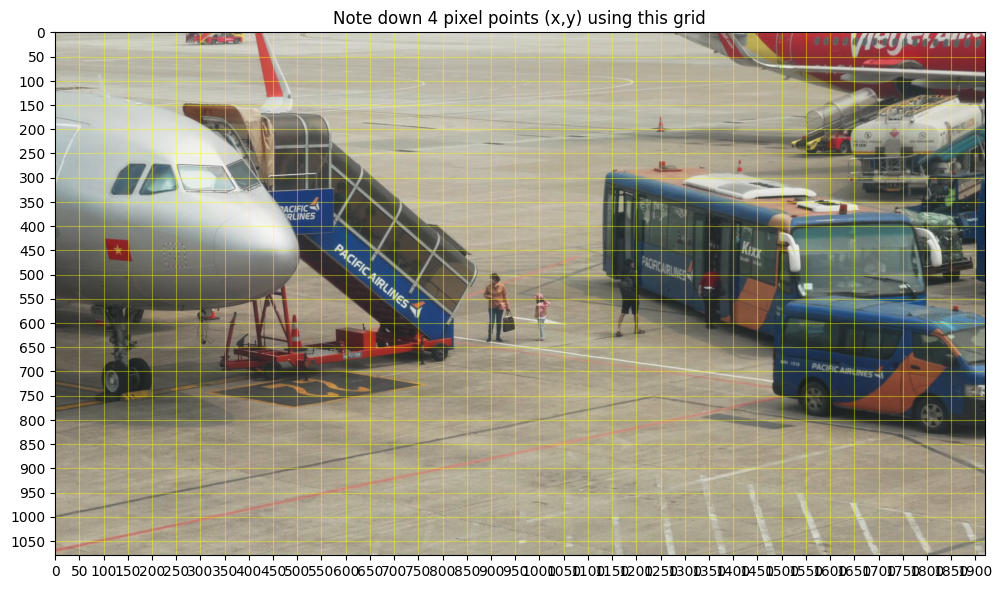

In [13]:
cap = cv2.VideoCapture("/content/drive/MyDrive/AirportVideo/airport.mp4")
ret, frame = cap.read()
cap.release()

if not ret:
    print("Failed to read frame — check your video path")
else:
    h, w = frame.shape[:2]
    print(f"Frame size: width={w}, height={h}")

    plt.figure(figsize=(12,7))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.xticks(np.arange(0, w, 50))
    plt.yticks(np.arange(0, h, 50))
    plt.grid(True, color='yellow', alpha=0.4)
    plt.title("Note down 4 pixel points (x,y) using this grid")
    plt.show()

In [15]:
# Replace these with the actual coordinates you read off the grid above
x1, y1 = 50, 400     # bottom-left
x2, y2 = 600, 400    # bottom-right
x3, y3 = 550, 100    # top-right
x4, y4 = 100, 100    # top-left

image_points = np.array([[x1,y1],[x2,y2],[x3,y3],[x4,y4]], dtype=np.float32)

# These should match the corners of your map's runway rectangle
map_points = np.array([[200, 500], [200, 300], [800, 300], [800, 500]], dtype=np.float32)

H, status = cv2.findHomography(image_points, map_points)
print("Homography matrix:\n", H)

Homography matrix:
 [[          0          -2        1064]
 [      -0.48        0.32         556]
 [          0      0.0008           1]]


In [16]:
def pixel_to_map(point, H):
    p = np.array([[point]], dtype=np.float32)
    mapped = cv2.perspectiveTransform(p, H)
    return tuple(mapped[0][0])

# Quick test — should map close to (0,0) since it's your bottom-left calibration point
test_point = (x1, y1)
print("Mapped point:", pixel_to_map(test_point, H))

Mapped point: (np.float32(200.0), np.float32(500.0))


## Phase 6: Zone-Aware Conflict Detection

Connects the tracking system to the airport map. Each detected object's
pixel position is converted to real map coordinates, then checked against
zones (restricted area, runways) and hold-short lines to generate
specific safety alerts instead of generic proximity warnings.

In [10]:
from matplotlib.path import Path

def get_zone_polygons(airport_map):
    """Convert airport_map coords into matplotlib Path objects for fast point-in-polygon checks."""
    zones = {}
    for name, zone in airport_map.items():
        zones[name] = {
            "path": Path(zone["coords"]),
            "type": zone["type"]
        }
    return zones

def check_zone_membership(map_point, zone_polygons):
    """Return list of zone names that contain this map point."""
    inside_zones = []
    for name, zone in zone_polygons.items():
        if zone["path"].contains_point(map_point):
            inside_zones.append((name, zone["type"]))
    return inside_zones

def distance_to_line(point, line_p1, line_p2):
    """Perpendicular distance from a point to a line segment (for hold-short proximity)."""
    p = np.array(point)
    a = np.array(line_p1)
    b = np.array(line_p2)
    ab = b - a
    ap = p - a
    t = np.clip(np.dot(ap, ab) / np.dot(ab, ab), 0, 1)
    closest = a + t * ab
    return np.linalg.norm(p - closest)

zone_polygons = get_zone_polygons(airport_map)

In [11]:
position_history = {}
map_position_history = {}
HISTORY_LENGTH = 10
HOLD_SHORT_THRESHOLD = 10  # meters, how close counts as "at" the hold-short line

csv_path = "/content/drive/MyDrive/AirportVideo/safety_alerts_v2.csv"
csvfile = open(csv_path, "w", newline="")
writer = csv.writer(csvfile)
writer.writerow(["Frame", "Time(s)", "Object_ID", "Object_Type",
                 "Map_X", "Map_Y", "Alert_Type", "Zone", "Severity"])

cap = cv2.VideoCapture("/content/drive/MyDrive/AirportVideo/airport.mp4")
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

frame_count = 0
total_alerts = 0
print("Generating zone-aware safety alert report...")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    results = model.track(frame, persist=True, conf=0.35, verbose=False)
    time_sec = round(frame_count / fps, 2)

    if results[0].boxes.id is not None:
        for box, obj_id, cls, conf in zip(
            results[0].boxes.xyxy,
            results[0].boxes.id,
            results[0].boxes.cls,
            results[0].boxes.conf
        ):
            obj_id = int(obj_id)
            label = model.names[int(cls)]
            x1b, y1b, x2b, y2b = box.tolist()
            pixel_center = (int((x1b+x2b)/2), int((y1b+y2b)/2))

            # Convert to map coordinates
            map_point = pixel_to_map(pixel_center, H)
            print(f"Frame {frame_count}: {label} at map position {map_point}")

            if obj_id not in map_position_history:
                map_position_history[obj_id] = deque(maxlen=HISTORY_LENGTH)
            map_position_history[obj_id].append(map_point)

            # --- Check 1: Zone membership (restricted zone entry) ---
            zones_here = check_zone_membership(map_point, zone_polygons)
            for zone_name, zone_type in zones_here:
                if zone_type == "restricted":
                    writer.writerow([frame_count, time_sec, obj_id, label,
                                     round(map_point[0],1), round(map_point[1],1),
                                     "RESTRICTED ZONE ENTRY", zone_name, "CRITICAL"])
                    total_alerts += 1

            # --- Check 2: Hold-short line proximity + runway entry ---
            for hs_name, (p1, p2) in hold_short_lines.items():
                d = distance_to_line(map_point, p1, p2)
                if d < HOLD_SHORT_THRESHOLD:
                    # object is at/near a hold-short line
                    # check if it's also inside a runway zone (i.e. crossed it)
                    for zone_name, zone_type in zones_here:
                        if zone_type == "runway":
                            writer.writerow([frame_count, time_sec, obj_id, label,
                                             round(map_point[0],1), round(map_point[1],1),
                                             f"RUNWAY INCURSION via {hs_name}", zone_name, "CRITICAL"])
                            total_alerts += 1
                    else:
                        writer.writerow([frame_count, time_sec, obj_id, label,
                                         round(map_point[0],1), round(map_point[1],1),
                                         f"AT HOLD-SHORT {hs_name}", hs_name, "MEDIUM"])
                        total_alerts += 1

    frame_count += 1
    print(f"Frame {frame_count}/{total_frames}", end="\r")

cap.release()
csvfile.close()
print(f"\nDone! Total zone-aware alerts logged: {total_alerts}")
print(f"Report saved to: {csv_path}")

Generating zone-aware safety alert report...
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 2 packages in 608ms
Prepared 1 package in 163ms
Installed 1 package in 4ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 1.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

Frame 0: bus at map position (np.float32(502.58066), np.float32(-4.354839))
Frame 0: airplane at map position (np.float32(74.597496), np.float32(-2.1735241))
Frame 0: person at map position (np.float32(293.08072), np.float32(-12.6771))
Frame 1: bus at map position (np.float32(505.16736), np.float32(-4.2014093))
Frame 1: airplane at map position (np.float32(74.255066), np.float32(-2.2526817))
Frame 1: person at map position (np.float32(292.96317), np.float32(-12.542605))
Frame 2: bus at map position (np.float32(504.22534), np.float32(-4.278169))
Frame 2: airplane at map position (np.float32(